<a href="https://colab.research.google.com/github/Zetastico/Interfaz_Veterinaria/blob/master/Laboratorio_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratorio 01

## Ejercicio de programación Regresión Lineal

### Preparación de Datos.

In [60]:
# utilizado para manejos de directorios y rutas
import os

import pandas as pd

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [61]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# Cargar el dataset usando Pandas

# Primero buscamos la direccion del dataset
# Para abrir con drive
path = '/content/drive/MyDrive/IA Dataset/Dataset_Regresion_Lineal_Simple.csv'
# Para abrir sin drive
# path = 'Dataset_Regresion_Lineal_Simple.csv'

# Y luego lo leemos
df = pd.read_csv(path)

# Seleccionar las 10 columnas numéricas n>=10
columnas_x = [
    'experience_years', 'weekly_hours', 'company_rating',
    'hiring_difficulty_score', 'ai_adoption_score', 'company_funding_billion',
    'economic_index', 'skill_demand_score', 'automation_risk', 'cost_of_living_index'
]

# Extraemos los datos (10000 filas)
X_mult = df[columnas_x].head(10000).values
y = df['salary_usd'].head(10000).values
m = y.size

### Normalizar los datos y añadir la columna de 1s

In [63]:
# Normalizar los datos
X_mean = np.mean(X_mult, axis=0)
X_std = np.std(X_mult, axis=0)
X_norm = (X_mult - X_mean) / X_std

# Agregar la columna de 1s
X_ready = np.stack([np.ones(m), X_norm[:,0], X_norm[:,1], X_norm[:,2], X_norm[:,3],
                    X_norm[:,4], X_norm[:,5], X_norm[:,6], X_norm[:,7],
                    X_norm[:,8], X_norm[:,9]], axis=1)

### Calcular el costo

In [64]:
def calcularCosto(X, y, theta):
    m = y.size
    J = 0
    # h = np.dot(X, theta)
    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))
    return J

### Descenso por el gradiente

In [65]:
def gradientDescent(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    # hace una copia de theta, para evitar cambiar la matriz original,
    # ya que las matrices numpy se pasan por referencia a las funciones
    theta = theta.copy()

    J_history = [] # Lista que se utiliza para almacenar el costo en cada iteración

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(calcularCosto(X, y, theta))

    return theta, J_history

### Entrenamiento

In [66]:
# inicializa los parametros de ajuste
theta = np.zeros(11)

# configuraciones para el descenso por el gradiente
iterations = 1500
alpha = 0.01

theta, J_history = gradientDescent(X_ready ,y, theta, alpha, iterations)
print('Theta encontrada por descenso gradiente: {:.4f}, {:.4f}'.format(*theta))
print('Costo en el último descenso de gradiente: {:.4f}'.format(J_history[-1]))
print(J_history)

Theta encontrada por descenso gradiente: 96196.8772, 31520.9204
Costo en el último descenso de gradiente: 453890169.1026
[np.float64(5476123128.27393), np.float64(5376171129.147875), np.float64(5278208559.782234), np.float64(5182195818.9679985), np.float64(5088094093.868298), np.float64(4995865344.3221), np.float64(4905472287.460448), np.float64(4816878382.629013), np.float64(4730047816.61086), np.float64(4644945489.143467), np.float64(4561536998.724106), np.float64(4479788628.69787), np.float64(4399667333.622722), np.float64(4321140725.905997), np.float64(4244177062.70704), np.float64(4168745233.1005926), np.float64(4094814745.495791), np.float64(4022355715.305669), np.float64(3951338852.8621683), np.float64(3881735451.5717845), np.float64(3813517376.3070426), np.float64(3746657052.029115), np.float64(3681127452.6369753), np.float64(3616902090.038574), np.float64(3553955003.4396267), np.float64(3492260748.845659), np.float64(3431794388.773092), np.float64(3372531482.1651797), np.float

### Inferencias

In [67]:
# Definimos los valores de las 10 columnas para el perfil que queremos consultar
# Orden: experience_years, weekly_hours, company_rating, hiring_difficulty,
# ai_adoption, funding, economic_index, skill_demand, automation_risk, cost_of_living
perfil_nuevo = np.array([5, 45, 4.2, 60, 85, 1.5, 0.8, 75, 30, 1.2])

# Normalizar el perfil completo
perfil_norm = (perfil_nuevo - X_mean) / X_std

# Aumentar el sesgo (1)
# Usamos np.append para que quede: [1, x1, x2, x3, x4, x5, x6, x7, x8, x9, x10]
x_lista = np.append(1, perfil_norm)

# Realizar la predicción con el Producto Punto
salario_predicho = np.dot(x_lista, theta)

print('--- Resultado de la Predicción Múltiple ---')
print(f'Para el perfil ingresado, el salario estimado es: ${salario_predicho:,.2f} USD')

--- Resultado de la Predicción Múltiple ---
Para el perfil ingresado, el salario estimado es: $85,498.02 USD


### Gráfico del costo J

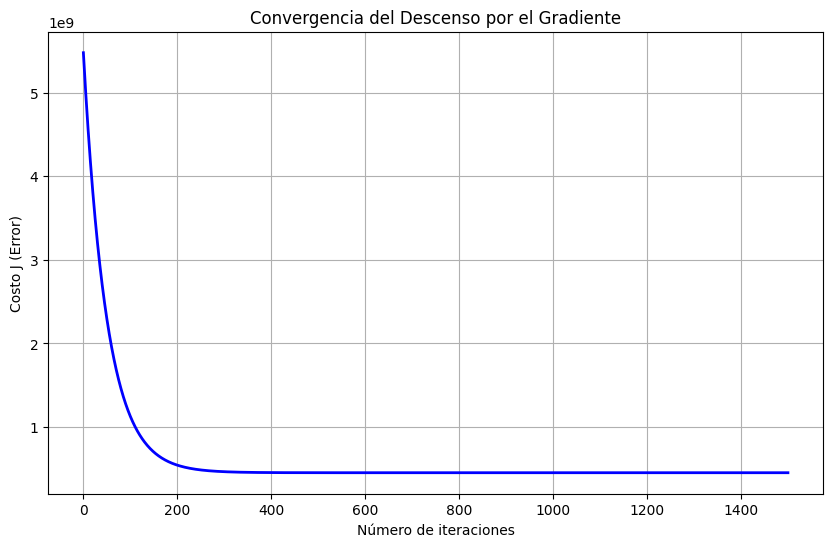

In [68]:
# Crear la figura
pyplot.figure(figsize=(10, 6))

# Graficar el historial de costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2, color='blue')

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J (Error)')
pyplot.title('Convergencia del Descenso por el Gradiente')
pyplot.grid(True)

pyplot.show()